2/15, 2/16, 2/17, 2/18 2026

#Abalation Studies

Hybrid Encoding Abalation: Removes the analog encoders and latent mapping

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
import time
import pickle
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# --- 1. NEUROMORPHIC BACKBONE (Manual Implementation) ---
class ATan(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return (x > 0).float()
    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        return grad_output / (1 + (np.pi * x)**2)

class ManualLIF(nn.Module):
    def __init__(self, beta=0.8, threshold=1.0):
        super().__init__()
        self.beta = beta
        self.threshold = threshold
        self.spike_fn = ATan.apply

    def forward(self, x, mem):
        spike = self.spike_fn(x + mem - self.threshold)
        mem = self.beta * mem + x - spike * self.threshold
        return spike, mem

# --- 2. BALANCED FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# --- 3. THE ABLATED ARCHITECTURE (NO ENCODERS) ---
class NoEncoderTempo(nn.Module):
    def __init__(self, omic_dims, n_hid_pow, n_out, steps=16):
        super().__init__()
        self.omic_dims = omic_dims
        self.total_dim = sum(omic_dims)
        self.n_hid = 2**(int(n_hid_pow) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)
        self.n_out = n_out

        # --- ABLATION: Modality Encoders are REMOVED ---

        # Gumbel Router: Operates on RAW Concatenated Data
        self.router = nn.Sequential(
            nn.Linear(self.total_dim, 64),
            nn.GELU(),
            nn.Linear(64, self.n_modalities)
        )

        # Fusion Net: Maps weighted raw features to hidden space
        self.fusion_net = nn.Linear(self.total_dim, self.n_hid)

        # Semantic Gate: FFT-based gating logic
        self.semantic_gate = nn.Sequential(
            nn.Linear(self.n_hid, self.n_hid),
            nn.Sigmoid()
        )

        # Spiking Backbone
        self.bn = nn.BatchNorm1d(self.n_hid)
        self.lif_short = ManualLIF(beta=0.7)
        self.lif_long = ManualLIF(beta=0.9)
        self.output_layer = nn.Linear(self.n_hid, n_out)

        self.spk_in_count = 0
        self.spk_hid_count = 0

    def forward(self, x_list, training=True):
        self.spk_in_count = 0
        self.spk_hid_count = 0

        # 1. Raw Concatenation
        cat_raw = torch.cat(x_list, dim=1)

        # 2. Gumbel Routing
        route_logits = self.router(cat_raw)
        route_weights = F.gumbel_softmax(route_logits, tau=1.0, hard=not training)

        # Apply routing to raw feature slices
        weighted_features = []
        curr = 0
        for i, dim in enumerate(self.omic_dims):
            weighted_features.append(cat_raw[:, curr:curr+dim] * route_weights[:, i].unsqueeze(-1))
            curr += dim

        # 3. Fusion and FFT Semantic Gating
        fused = self.fusion_net(torch.cat(weighted_features, dim=1))
        f_trans = torch.fft.rfft(fused, dim=-1).abs()
        # Pad FFT to match hidden dimension for gating
        gate = self.semantic_gate(F.pad(f_trans, (0, fused.shape[-1] - f_trans.shape[-1])))
        modulated_vec = fused * gate

        # 4. Neuromorphic Temporal Processing
        spk_rec = []
        m_s = torch.zeros_like(modulated_vec)
        m_l = torch.zeros_like(modulated_vec)

        for t in range(self.steps):
            # Rate encoding the gated signal
            in_spk = (torch.rand_like(modulated_vec) < torch.sigmoid(self.bn(modulated_vec))).float()
            self.spk_in_count += in_spk.sum().item()

            s, m_s = self.lif_short(in_spk, m_s)
            l, m_l = self.lif_long(in_spk, m_l)
            out_spk = torch.max(s, l)
            spk_rec.append(out_spk)
            self.spk_hid_count += out_spk.sum().item()

        return self.output_layer(torch.stack(spk_rec).mean(0))

    def calculate_efficiency(self, batch_size):
        # DL Complexity (FLOPs)
        router_f = (self.total_dim * 64) + (64 * self.n_modalities)
        fusion_f = (self.total_dim * self.n_hid)
        gate_f = (self.n_hid * self.n_hid)
        total_flops = router_f + fusion_f + gate_f

        # Spiking Complexity (SynOps)
        total_synops = (self.spk_in_count + (self.spk_hid_count * self.n_out)) / batch_size
        return total_flops, total_synops

# --- 4. DATA PIPELINE & EVALUATION ---
def run_ablation():
    # Load data
    with open('processed_data.pkl', 'rb') as f:
        data = pickle.load(f)

    X_train, X_test = data['X_train'], data['X_test']
    y_train, y_test = data['y_train'], data['y_test']
    omic_dims = data['omic_dims']

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)
    n_classes = len(le.classes_)

    class_weights = torch.tensor(np.sqrt(len(y_train_enc) / (np.bincount(y_train_enc) * n_classes)), dtype=torch.float)

    def to_list(X, dims):
        curr, out = 0, []
        for d in dims:
            out.append(torch.tensor(X[:, curr:curr+d]).float())
            curr += d
        return out

    results_log = []
    seeds = [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]

    print(f"Starting No-Encoder Ablation across {len(seeds)} seeds...")

    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)

        x_train_list = to_list(X_train, omic_dims)
        x_test_list = to_list(X_test, omic_dims)

        train_loader = DataLoader(
            TensorDataset(*x_train_list, torch.tensor(y_train_enc)),
            batch_size=64,
            sampler=WeightedRandomSampler(class_weights[y_train_enc], len(y_train_enc))
        )

        model = NoEncoderTempo(omic_dims, 9, n_classes)
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
        criterion = FocalLoss(alpha=class_weights, gamma=1.0)

        # Training (50 Epochs)
        for epoch in range(50):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()
                logits = model(batch[:-1])
                loss = criterion(logits, batch[-1])
                loss.backward(); optimizer.step()

        # Full Evaluation Suite
        model.eval()
        with torch.no_grad():
            start_lat = time.time()
            logits = model(x_test_list, training=False)
            latency = (time.time() - start_lat) / len(y_test_enc)
            flops, synops = model.calculate_efficiency(len(y_test_enc))

            probs = torch.softmax(logits, dim=1).numpy()
            preds = torch.argmax(logits, dim=1).numpy()

        # Metric Calculations
        y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))
        cm = confusion_matrix(y_test_enc, preds)

        specs, npvs = [], []
        for i in range(n_classes):
            tp = cm[i, i]
            fp = cm[:, i].sum() - tp
            fn = cm[i, :].sum() - tp
            tn = cm.sum() - (tp + fp + fn)
            specs.append(tn / (tn + fp + 1e-9))
            npvs.append(tn / (tn + fn + 1e-9))

        results_log.append({
            "Seed": seed,
            "Accuracy": accuracy_score(y_test_enc, preds),
            "Balanced Accuracy": balanced_accuracy_score(y_test_enc, preds),
            "AUC (Macro)": roc_auc_score(y_test_bin, probs, multi_class='ovr', average='macro'),
            "AUCPRC (Macro)": average_precision_score(y_test_bin, probs, average='macro'),
            "F1 Macro": f1_score(y_test_enc, preds, average='macro'),
            "PPV (Precision)": precision_score(y_test_enc, preds, average='macro', zero_division=0),
            "NPV": np.mean(npvs),
            "Sensitivity (Recall)": recall_score(y_test_enc, preds, average='macro'),
            "Specificity": np.mean(specs),
            "FLOPs/Sample": flops,
            "SynOps/Sample": synops,
            "Latency": latency
        })
        print(f"Seed {seed} Complete. Acc: {results_log[-1]['Accuracy']:.4f}")

    df = pd.DataFrame(results_log)
    df.to_csv("TEMPO_ABLATION_NO_ENCODER_ALL_METRICS.csv", index=False)
    print("\n--- FINAL ABLATION AVERAGES ---")
    print(df.drop(columns='Seed').mean())

if __name__ == "__main__":
    run_ablation()

Starting No-Encoder Ablation across 10 seeds...
Seed 42 Complete. Acc: 0.0815
Seed 1 Complete. Acc: 0.0889
Seed 7 Complete. Acc: 0.0988
Seed 13 Complete. Acc: 0.1440
Seed 21 Complete. Acc: 0.1185
Seed 69 Complete. Acc: 0.1556
Seed 88 Complete. Acc: 0.1144
Seed 101 Complete. Acc: 0.1424
Seed 404 Complete. Acc: 0.0988
Seed 777 Complete. Acc: 0.1243

--- FINAL ABLATION AVERAGES ---
Accuracy                     0.116708
Balanced Accuracy            0.121488
AUC (Macro)                  0.711408
AUCPRC (Macro)               0.108853
F1 Macro                     0.078093
PPV (Precision)              0.086427
NPV                          0.978339
Sensitivity (Recall)         0.121488
Specificity                  0.978318
FLOPs/Sample            121728.000000
SynOps/Sample             4891.552428
Latency                      0.000014
dtype: float64


Semantic Addressing Abalation: Removes Semantic Context from addressing and FFT Semantic Gate filtering

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
import time
import pickle
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# --- 1. NEUROMORPHIC BACKBONE (Manual LIF for Dependency-Free Execution) ---
class ATan(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return (x > 0).float()
    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        return grad_output / (1 + (np.pi * x)**2)

class ManualLIF(nn.Module):
    def __init__(self, beta=0.8, threshold=1.0):
        super().__init__()
        self.beta = beta
        self.threshold = threshold
        self.spike_fn = ATan.apply

    def forward(self, x, mem):
        spike = self.spike_fn(x + mem - self.threshold)
        mem = self.beta * mem + x - spike * self.threshold
        return spike, mem

# --- 2. BALANCED FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        return (((1 - pt) ** self.gamma) * ce_loss).mean()

# --- 3. ABLATED ARCHITECTURE: NO SEMANTIC ADDRESSING ---
class NoSemanticTempo(nn.Module):
    def __init__(self, omic_dims, n_hid_pow, n_out, steps=16):
        super().__init__()
        self.omic_dims = omic_dims
        self.n_modalities = len(omic_dims)
        self.n_hid = 2**(int(n_hid_pow) - 1).bit_length()
        self.steps = steps
        self.n_out = n_out

        # 1. Hybrid Encoders (KEPT)
        self.encoders = nn.ModuleList([nn.Linear(d, 128) for d in omic_dims])

        # 2. Gumbel Router (KEPT)
        self.router = nn.Sequential(
            nn.Linear(128 * self.n_modalities, 64),
            nn.GELU(),
            nn.Linear(64, self.n_modalities)
        )

        # 3. Fusion Layer
        self.fusion_net = nn.Linear(128 * self.n_modalities, self.n_hid)

        # --- ABLATION: Semantic FFT Gate and Addressing logic are REMOVED ---
        # No self.semantic_gate = nn.Sequential(...)

        # 4. Spiking Backbone
        self.bn = nn.BatchNorm1d(self.n_hid)
        self.lif_short = ManualLIF(beta=0.7)
        self.lif_long = ManualLIF(beta=0.9)
        self.output_layer = nn.Linear(self.n_hid, n_out)

        self.spk_in_count = 0
        self.spk_hid_count = 0

    def forward(self, x_list, training=True):
        self.spk_in_count = 0
        self.spk_hid_count = 0

        # Encoding
        latents = [F.gelu(self.encoders[i](x_list[i])) for i in range(self.n_modalities)]
        cat_latents = torch.cat(latents, dim=1)

        # Gumbel Routing
        route_logits = self.router(cat_latents)
        route_weights = F.gumbel_softmax(route_logits, tau=1.0, hard=not training)

        # Weighted Fusion
        modulated_latents = []
        for i in range(self.n_modalities):
            modulated_latents.append(latents[i] * route_weights[:, i].unsqueeze(-1))

        # --- ABLATION: Fused vector bypasses the FFT and Gate entirely ---
        fused_vec = self.fusion_net(torch.cat(modulated_latents, dim=1))

        # Temporal Spiking Processing
        spk_rec = []
        m_s = torch.zeros_like(fused_vec)
        m_l = torch.zeros_like(fused_vec)

        for t in range(self.steps):
            # Poisson-rate encoding based on raw fused intensity
            in_spk = (torch.rand_like(fused_vec) < torch.sigmoid(self.bn(fused_vec))).float()
            self.spk_in_count += in_spk.sum().item()

            s, m_s = self.lif_short(in_spk, m_s)
            l, m_l = self.lif_long(in_spk, m_l)
            out_spk = torch.max(s, l)
            spk_rec.append(out_spk)
            self.spk_hid_count += out_spk.sum().item()

        return self.output_layer(torch.stack(spk_rec).mean(0))

    def calculate_efficiency(self, batch_size):
        # Encoders + Router + Fusion
        enc_f = sum([d * 128 for d in self.omic_dims])
        router_f = (128 * self.n_modalities * 64) + (64 * self.n_modalities)
        fusion_f = (128 * self.n_modalities * self.n_hid)
        total_flops = enc_f + router_f + fusion_f

        # SynOps (No SynOps for gating since it was removed)
        total_synops = (self.spk_in_count + (self.spk_hid_count * self.n_out)) / batch_size
        return total_flops, total_synops

# --- 4. DATA LOADING & FULL METRIC EVALUATION ---
def run_ablation():
    try:
        with open('processed_data.pkl', 'rb') as f:
            data = pickle.load(f)
    except FileNotFoundError:
        print("Error: processed_data.pkl not found. Ensure data is prepared.")
        return

    le = LabelEncoder()
    y_train_enc = le.fit_transform(data['y_train'])
    y_test_enc = le.transform(data['y_test'])
    n_classes = len(le.classes_)

    class_weights = torch.tensor(np.sqrt(len(y_train_enc) / (np.bincount(y_train_enc) * n_classes)), dtype=torch.float)

    def to_list(X, dims):
        curr, out = 0, []
        for d in dims:
            out.append(torch.tensor(X[:, curr:curr+d]).float())
            curr += d
        return out

    results_log = []
    seeds = [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]

    print(f"Starting 'No-Semantic Addressing' Ablation (10 Seeds)...")

    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)

        x_train_list = to_list(data['X_train'], data['omic_dims'])
        x_test_list = to_list(data['X_test'], data['omic_dims'])

        train_loader = DataLoader(
            TensorDataset(*x_train_list, torch.tensor(y_train_enc)),
            batch_size=64,
            sampler=WeightedRandomSampler(class_weights[y_train_enc], len(y_train_enc))
        )

        model = NoSemanticTempo(data['omic_dims'], 9, n_classes)
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
        criterion = FocalLoss(alpha=class_weights, gamma=1.0)

        # Train for 50 Epochs
        for epoch in range(50):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()
                logits = model(batch[:-1])
                loss = criterion(logits, batch[-1])
                loss.backward(); optimizer.step()

        # Evaluate all 13 metrics
        model.eval()
        with torch.no_grad():
            start_lat = time.time()
            logits = model(x_test_list, training=False)
            latency = (time.time() - start_lat) / len(y_test_enc)
            flops, synops = model.calculate_efficiency(len(y_test_enc))

            probs = torch.softmax(logits, dim=1).numpy()
            preds = torch.argmax(logits, dim=1).numpy()

        y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))
        cm = confusion_matrix(y_test_enc, preds)

        # NPV and Specificity
        specs, npvs = [], []
        for i in range(n_classes):
            tp = cm[i, i]
            fp = cm[:, i].sum() - tp
            fn = cm[i, :].sum() - tp
            tn = cm.sum() - (tp + fp + fn)
            specs.append(tn / (tn + fp + 1e-9))
            npvs.append(tn / (tn + fn + 1e-9))

        results_log.append({
            "Seed": seed,
            "Accuracy": accuracy_score(y_test_enc, preds),
            "Balanced Accuracy": balanced_accuracy_score(y_test_enc, preds),
            "AUC (Macro)": roc_auc_score(y_test_bin, probs, multi_class='ovr', average='macro'),
            "AUCPRC (Macro)": average_precision_score(y_test_bin, probs, average='macro'),
            "F1 Macro": f1_score(y_test_enc, preds, average='macro'),
            "PPV (Precision)": precision_score(y_test_enc, preds, average='macro', zero_division=0),
            "NPV": np.mean(npvs),
            "Sensitivity (Recall)": recall_score(y_test_enc, preds, average='macro'),
            "Specificity": np.mean(specs),
            "FLOPs/Sample": flops,
            "SynOps/Sample": synops,
            "Latency": latency
        })
        print(f"Seed {seed} | Accuracy: {results_log[-1]['Accuracy']:.4f}")

    # Output CSV and summary statistics
    df = pd.DataFrame(results_log)
    df.to_csv("TEMPO_ABLATION_NO_SEMANTIC_ADDRESSING.csv", index=False)
    print("\n--- ABLATION SUMMARY: NO SEMANTIC ADDRESSING ---")
    print(df.drop(columns='Seed').mean())

if __name__ == "__main__":
    run_ablation()

Starting 'No-Semantic Addressing' Ablation (10 Seeds)...
Seed 42 | Accuracy: 0.0947
Seed 1 | Accuracy: 0.1045
Seed 7 | Accuracy: 0.0749
Seed 13 | Accuracy: 0.1045
Seed 21 | Accuracy: 0.0905
Seed 69 | Accuracy: 0.0782
Seed 88 | Accuracy: 0.0658
Seed 101 | Accuracy: 0.0807
Seed 404 | Accuracy: 0.1111
Seed 777 | Accuracy: 0.0971

--- ABLATION SUMMARY: NO SEMANTIC ADDRESSING ---
Accuracy                     0.090206
Balanced Accuracy            0.101066
AUC (Macro)                  0.690930
AUCPRC (Macro)               0.101096
F1 Macro                     0.063341
PPV (Precision)              0.077660
NPV                          0.977751
Sensitivity (Recall)         0.101066
Specificity                  0.977738
FLOPs/Sample            224960.000000
SynOps/Sample             4812.703539
Latency                      0.000012
dtype: float64


Differentiable Category Routing Abalation: Removes Gumbel-Softmax and routing logic

In [ ]:
!pip install snntorch
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
import time
from snntorch import surrogate, leaky, spikegen
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# --- 1. BALANCED FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# --- 2. TEMPO ABLATION: REMOVED DIFFERENTIABLE CATEGORICAL ROUTING ---
class TempoAblationNoRouting(nn.Module):
    def __init__(self, omic_dims, n_hid, n_out, steps=16):
        super().__init__()
        self.omic_dims = omic_dims
        self.n_hid_fft = 2**(int(n_hid) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)
        self.n_out = n_out

        # Analog Front-end
        self.encoders = nn.ModuleList([
            nn.Sequential(nn.Linear(d, 128), nn.BatchNorm1d(128), nn.GELU()) for d in omic_dims
        ])

        # FIXED FUSION (Ablated: No Router/Gumbel-Softmax)
        self.fusion_net = nn.Linear(128 * self.n_modalities, self.n_hid_fft)

        # Spiking Back-end
        self.spike_bn = nn.BatchNorm1d(self.n_hid_fft)
        self.spa_pointer = nn.Parameter(torch.randn(self.n_hid_fft))
        self.jitter = nn.Parameter(torch.randn(steps, self.n_hid_fft) * 0.01)
        self.lif_short = leaky.Leaky(beta=0.75, spike_grad=surrogate.atan(), init_hidden=False)
        self.lif_long = leaky.Leaky(beta=0.9, spike_grad=surrogate.atan(), init_hidden=False)
        self.output_layer = nn.Linear(self.n_hid_fft, n_out)

        self.spk_in_count = 0
        self.spk_hid_count = 0

    def forward(self, x_omics, training=True):
        self.spk_in_count = 0
        self.spk_hid_count = 0

        # Encode each modality
        enc_outs = [enc(x) for enc, x in zip(self.encoders, x_omics)]

        # ABLATION STEP: Concatenate directly without Gumbel-Softmax weighting
        cat_vec = torch.cat(enc_outs, dim=-1)
        fused_vec = self.fusion_net(cat_vec)

        # Semantic Addressing (FFT logic remains)
        x_fft = torch.fft.rfft(fused_vec, n=self.n_hid_fft)
        p_fft = torch.fft.rfft(self.spa_pointer, n=self.n_hid_fft)
        semantic_gate = torch.sigmoid(torch.fft.irfft(x_fft * torch.conj(p_fft), n=self.n_hid_fft))

        spk_in = spikegen.rate(torch.sigmoid(fused_vec), num_steps=self.steps)
        self.spk_in_count = spk_in.sum().item()

        spk_rec = []
        m_s, m_l = self.lif_short.init_leaky(), self.lif_long.init_leaky()
        for t in range(self.steps):
            curr = self.spike_bn(spk_in[t] * torch.sigmoid(semantic_gate + self.jitter[t]))
            s, m_s = self.lif_short(curr, m_s)
            l, m_l = self.lif_long(curr, m_l)
            out_spk = torch.max(s, l)
            spk_rec.append(out_spk)
            self.spk_hid_count += out_spk.sum().item()

        return self.output_layer(torch.stack(spk_rec).mean(0)), torch.stack(spk_rec)

    def calculate_efficiency(self, batch_size):
        enc_flops = sum([d * 128 for d in self.omic_dims])
        # Router FLOPs removed from this calculation
        fusion_flops = (128 * self.n_modalities * self.n_hid_fft)
        fft_flops = 5 * self.n_hid_fft * np.log2(self.n_hid_fft + 1e-9)
        total_flops = enc_flops + fusion_flops + fft_flops
        total_synops = (self.spk_in_count + (self.spk_hid_count * self.n_out)) / batch_size
        return total_flops, total_synops

# --- 3. EXECUTION ---
with open('PANCAN_TEMPO_Input_Data.pkl', 'rb') as f:
    data_pkl = pickle.load(f)

le = LabelEncoder()
y_train_enc = le.fit_transform(data_pkl['y_train'])
y_test_enc = le.transform(data_pkl['y_test'])
n_classes = len(le.classes_)

class_counts = np.bincount(y_train_enc)
soft_weights = torch.tensor(np.sqrt(len(y_train_enc) / (class_counts * n_classes)), dtype=torch.float)

def split_to_list(X, dims):
    curr, out = 0, []
    for d in dims: out.append(torch.tensor(X[:, curr:curr+d]).float()); curr += d
    return out

results_log = []
seeds = [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    x_train_list = split_to_list(data_pkl['X_train'], data_pkl['omic_dims'])
    x_test_list = split_to_list(data_pkl['X_test'], data_pkl['omic_dims'])

    sampler = WeightedRandomSampler(soft_weights[y_train_enc], len(y_train_enc))
    train_loader = DataLoader(TensorDataset(*x_train_list, torch.tensor(y_train_enc)), batch_size=64, sampler=sampler)

    # Use the Ablated Model
    model = TempoAblationNoRouting(data_pkl['omic_dims'], 9, n_classes)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    criterion = FocalLoss(alpha=soft_weights, gamma=1.0)

    for epoch in range(50):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits, _ = model(batch[:-1])
            loss = criterion(logits, batch[-1])
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        start_lat = time.time()
        logits, _ = model(x_test_list, training=False)
        latency = (time.time() - start_lat) / len(y_test_enc)
        flops_per_sample, synops_per_sample = model.calculate_efficiency(len(y_test_enc))

        probs = torch.softmax(logits, dim=1).numpy()
        preds = torch.argmax(logits, dim=1).numpy()

    # Metrics
    y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))
    cm = confusion_matrix(y_test_enc, preds)
    specs, npvs = [], []
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp + 1e-9))
        npvs.append(tn / (tn + fn + 1e-9))

    results_log.append({
        "Seed": seed,
        "Ablation": "No_Routing",
        "Accuracy": accuracy_score(y_test_enc, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_test_enc, preds),
        "AUC (Macro)": roc_auc_score(y_test_bin, probs, multi_class='ovr', average='macro'),
        "AUCPRC (Macro)": average_precision_score(y_test_bin, probs, average='macro'),
        "F1 Macro": f1_score(y_test_enc, preds, average='macro'),
        "PPV (Precision)": precision_score(y_test_enc, preds, average='macro', zero_division=0),
        "NPV": np.mean(npvs),
        "Sensitivity (Recall)": recall_score(y_test_enc, preds, average='macro'),
        "Specificity": np.mean(specs),
        "FLOPs/Sample": flops_per_sample,
        "SynOps/Sample": synops_per_sample,
        "Latency": latency
    })
    print(f"Seed {seed} | [No Routing] | Acc: {results_log[-1]['Accuracy']:.4f} | SynOps: {synops_per_sample:.2e} | FLOPs: {flops_per_sample:.2e}")

pd.DataFrame(results_log).to_csv("TEMPO_ABLATION_NO_ROUTING.csv", index=False)

Balanced Focal Learning Abalation: Removes the subfeatures of focal loss and weighted random sampling

In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import time
from snntorch import surrogate, leaky, spikegen
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# --- 1. ABLATED TEMPO ---
# Keeping the architecture the same as the previous ablation to isolate the loss/sampling impact
class TempoAblated(nn.Module):
    def __init__(self, omic_dims, n_hid, n_out, steps=16):
        super().__init__()
        self.omic_dims = omic_dims
        self.n_hid_fft = 2**(int(n_hid) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)
        self.n_out = n_out

        # Analog Front-end
        self.encoders = nn.ModuleList([
            nn.Sequential(nn.Linear(d, 128), nn.BatchNorm1d(128), nn.GELU()) for d in omic_dims
        ])
        self.router = nn.Sequential(
            nn.Linear(128 * self.n_modalities, 64),
            nn.GELU(),
            nn.Linear(64, self.n_modalities)
        )
        self.fusion_net = nn.Linear(128 * self.n_modalities, self.n_hid_fft)

        self.spike_bn = nn.BatchNorm1d(self.n_hid_fft)
        self.spa_pointer = nn.Parameter(torch.randn(self.n_hid_fft))

        # Standard LIF
        self.lif = leaky.Leaky(beta=0.8, spike_grad=surrogate.atan(), init_hidden=False)
        self.output_layer = nn.Linear(self.n_hid_fft, n_out)

        self.spk_in_count = 0
        self.spk_hid_count = 0

    def forward(self, x_omics, training=True):
        self.spk_in_count = 0
        self.spk_hid_count = 0

        enc_outs = [enc(x) for enc, x in zip(self.encoders, x_omics)]
        cat_vec = torch.cat(enc_outs, dim=-1)
        route_weights = F.gumbel_softmax(self.router(cat_vec), tau=0.8, hard=not training)

        fused_vec = self.fusion_net(torch.cat([
            enc_outs[i] * route_weights[:, i].unsqueeze(-1) for i in range(self.n_modalities)
        ], dim=-1))

        x_fft = torch.fft.rfft(fused_vec, n=self.n_hid_fft)
        p_fft = torch.fft.rfft(self.spa_pointer, n=self.n_hid_fft)
        semantic_gate = torch.sigmoid(torch.fft.irfft(x_fft * torch.conj(p_fft), n=self.n_hid_fft))

        spk_in = spikegen.rate(torch.sigmoid(fused_vec), num_steps=self.steps)
        self.spk_in_count = spk_in.sum().item()

        spk_rec = []
        mem = self.lif.init_leaky()

        for t in range(self.steps):
            curr = self.spike_bn(spk_in[t] * semantic_gate)
            spk, mem = self.lif(curr, mem)
            spk_rec.append(spk)
            self.spk_hid_count += spk.sum().item()

        return self.output_layer(torch.stack(spk_rec).mean(0)), torch.stack(spk_rec)

    def calculate_efficiency(self, batch_size):
        enc_flops = sum([d * 128 for d in self.omic_dims])
        router_flops = (128 * self.n_modalities * 64) + (64 * self.n_modalities)
        fusion_flops = (128 * self.n_modalities * self.n_hid_fft)
        fft_flops = 5 * self.n_hid_fft * np.log2(self.n_hid_fft + 1e-9)
        total_flops = enc_flops + router_flops + fusion_flops + fft_flops
        total_synops = (self.spk_in_count + (self.spk_hid_count * self.n_out)) / batch_size
        return total_flops, total_synops

# --- 2. EXECUTION ---
with open('PANCAN_TEMPO_Input_Data.pkl', 'rb') as f:
    data_pkl = pickle.load(f)

le = LabelEncoder()
y_train_enc = le.fit_transform(data_pkl['y_train'])
y_test_enc = le.transform(data_pkl['y_test'])
n_classes = len(le.classes_)

def split_to_list(X, dims):
    curr, out = 0, []
    for d in dims: out.append(torch.tensor(X[:, curr:curr+d]).float()); curr += d
    return out

results_log = []
seeds = [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    x_train_list = split_to_list(data_pkl['X_train'], data_pkl['omic_dims'])
    x_test_list = split_to_list(data_pkl['X_test'], data_pkl['omic_dims'])

    # ABLATION: Standard DataLoader with shuffle=True instead of WeightedSampler
    train_loader = DataLoader(
        TensorDataset(*x_train_list, torch.tensor(y_train_enc)),
        batch_size=64,
        shuffle=True
    )

    model = TempoAblated(data_pkl['omic_dims'], 9, n_classes)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

    # ABLATION: Standard CrossEntropyLoss instead of Focal Loss
    criterion = nn.CrossEntropyLoss()

    for epoch in range(50):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits, _ = model(batch[:-1])
            loss = criterion(logits, batch[-1])
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        start_lat = time.time()
        logits, _ = model(x_test_list, training=False)
        latency = (time.time() - start_lat) / len(y_test_enc)
        flops_per_sample, synops_per_sample = model.calculate_efficiency(len(y_test_enc))

        probs = torch.softmax(logits, dim=1).numpy()
        preds = torch.argmax(logits, dim=1).numpy()

    # Metrics
    y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))
    cm = confusion_matrix(y_test_enc, preds)
    specs, npvs = [], []
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp + 1e-9))
        npvs.append(tn / (tn + fn + 1e-9))

    results_log.append({
        "Seed": seed,
        "Ablation": "No_Focal_No_Sampling",
        "Accuracy": accuracy_score(y_test_enc, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_test_enc, preds),
        "AUC (Macro)": roc_auc_score(y_test_bin, probs, multi_class='ovr', average='macro'),
        "AUCPRC (Macro)": average_precision_score(y_test_bin, probs, average='macro'),
        "F1 Macro": f1_score(y_test_enc, preds, average='macro'),
        "PPV (Precision)": precision_score(y_test_enc, preds, average='macro', zero_division=0),
        "NPV": np.mean(npvs),
        "Sensitivity (Recall)": recall_score(y_test_enc, preds, average='macro'),
        "Specificity": np.mean(specs),
        "FLOPs/Sample": flops_per_sample,
        "SynOps/Sample": synops_per_sample,
        "Latency": latency
    })
    print(f"Seed {seed} | [Ablation: No Focal/Sampling] | Acc: {results_log[-1]['Accuracy']:.4f}")

pd.DataFrame(results_log).to_csv("Balanced_Focal_Learning_Abalation.csv", index=False)

Seed 42 | [Ablation: No Focal/Sampling] | Acc: 0.7844
Seed 1 | [Ablation: No Focal/Sampling] | Acc: 0.7802
Seed 7 | [Ablation: No Focal/Sampling] | Acc: 0.8058
Seed 13 | [Ablation: No Focal/Sampling] | Acc: 0.7967
Seed 21 | [Ablation: No Focal/Sampling] | Acc: 0.8008
Seed 69 | [Ablation: No Focal/Sampling] | Acc: 0.7967
Seed 88 | [Ablation: No Focal/Sampling] | Acc: 0.7778
Seed 101 | [Ablation: No Focal/Sampling] | Acc: 0.8008
Seed 404 | [Ablation: No Focal/Sampling] | Acc: 0.7934
Seed 777 | [Ablation: No Focal/Sampling] | Acc: 0.7918


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load all datasets
file_map = {
    "Main TEMPO": "PANCAN_TEMPO_Metrics.csv",
    "No BFL + WRS": "BFL_WRS_Abalation.csv",
    "No Hybrid Enc": "Hybrid_Encoding_Abalation.csv",
    "No Routing": "Router_Abalation.csv",
    "No Semantic Addr": "Semantic_Addressing_Abalation.csv",
}

dfs = []
for label, path in file_map.items():
    try:
        temp_df = pd.read_csv(path)
        temp_df['Model'] = label
        dfs.append(temp_df)
    except FileNotFoundError:
        print(f"Warning: {path} not found. Skipping...")

full_data = pd.concat(dfs, ignore_index=True)

# Define core metrics for plotting
metrics = ["Accuracy", "Balanced Accuracy", "AUC (Macro)", "AUCPRC (Macro)", "F1 Macro", "Sensitivity (Recall)", "PPV (Precision)"]

Visualize performance metrics

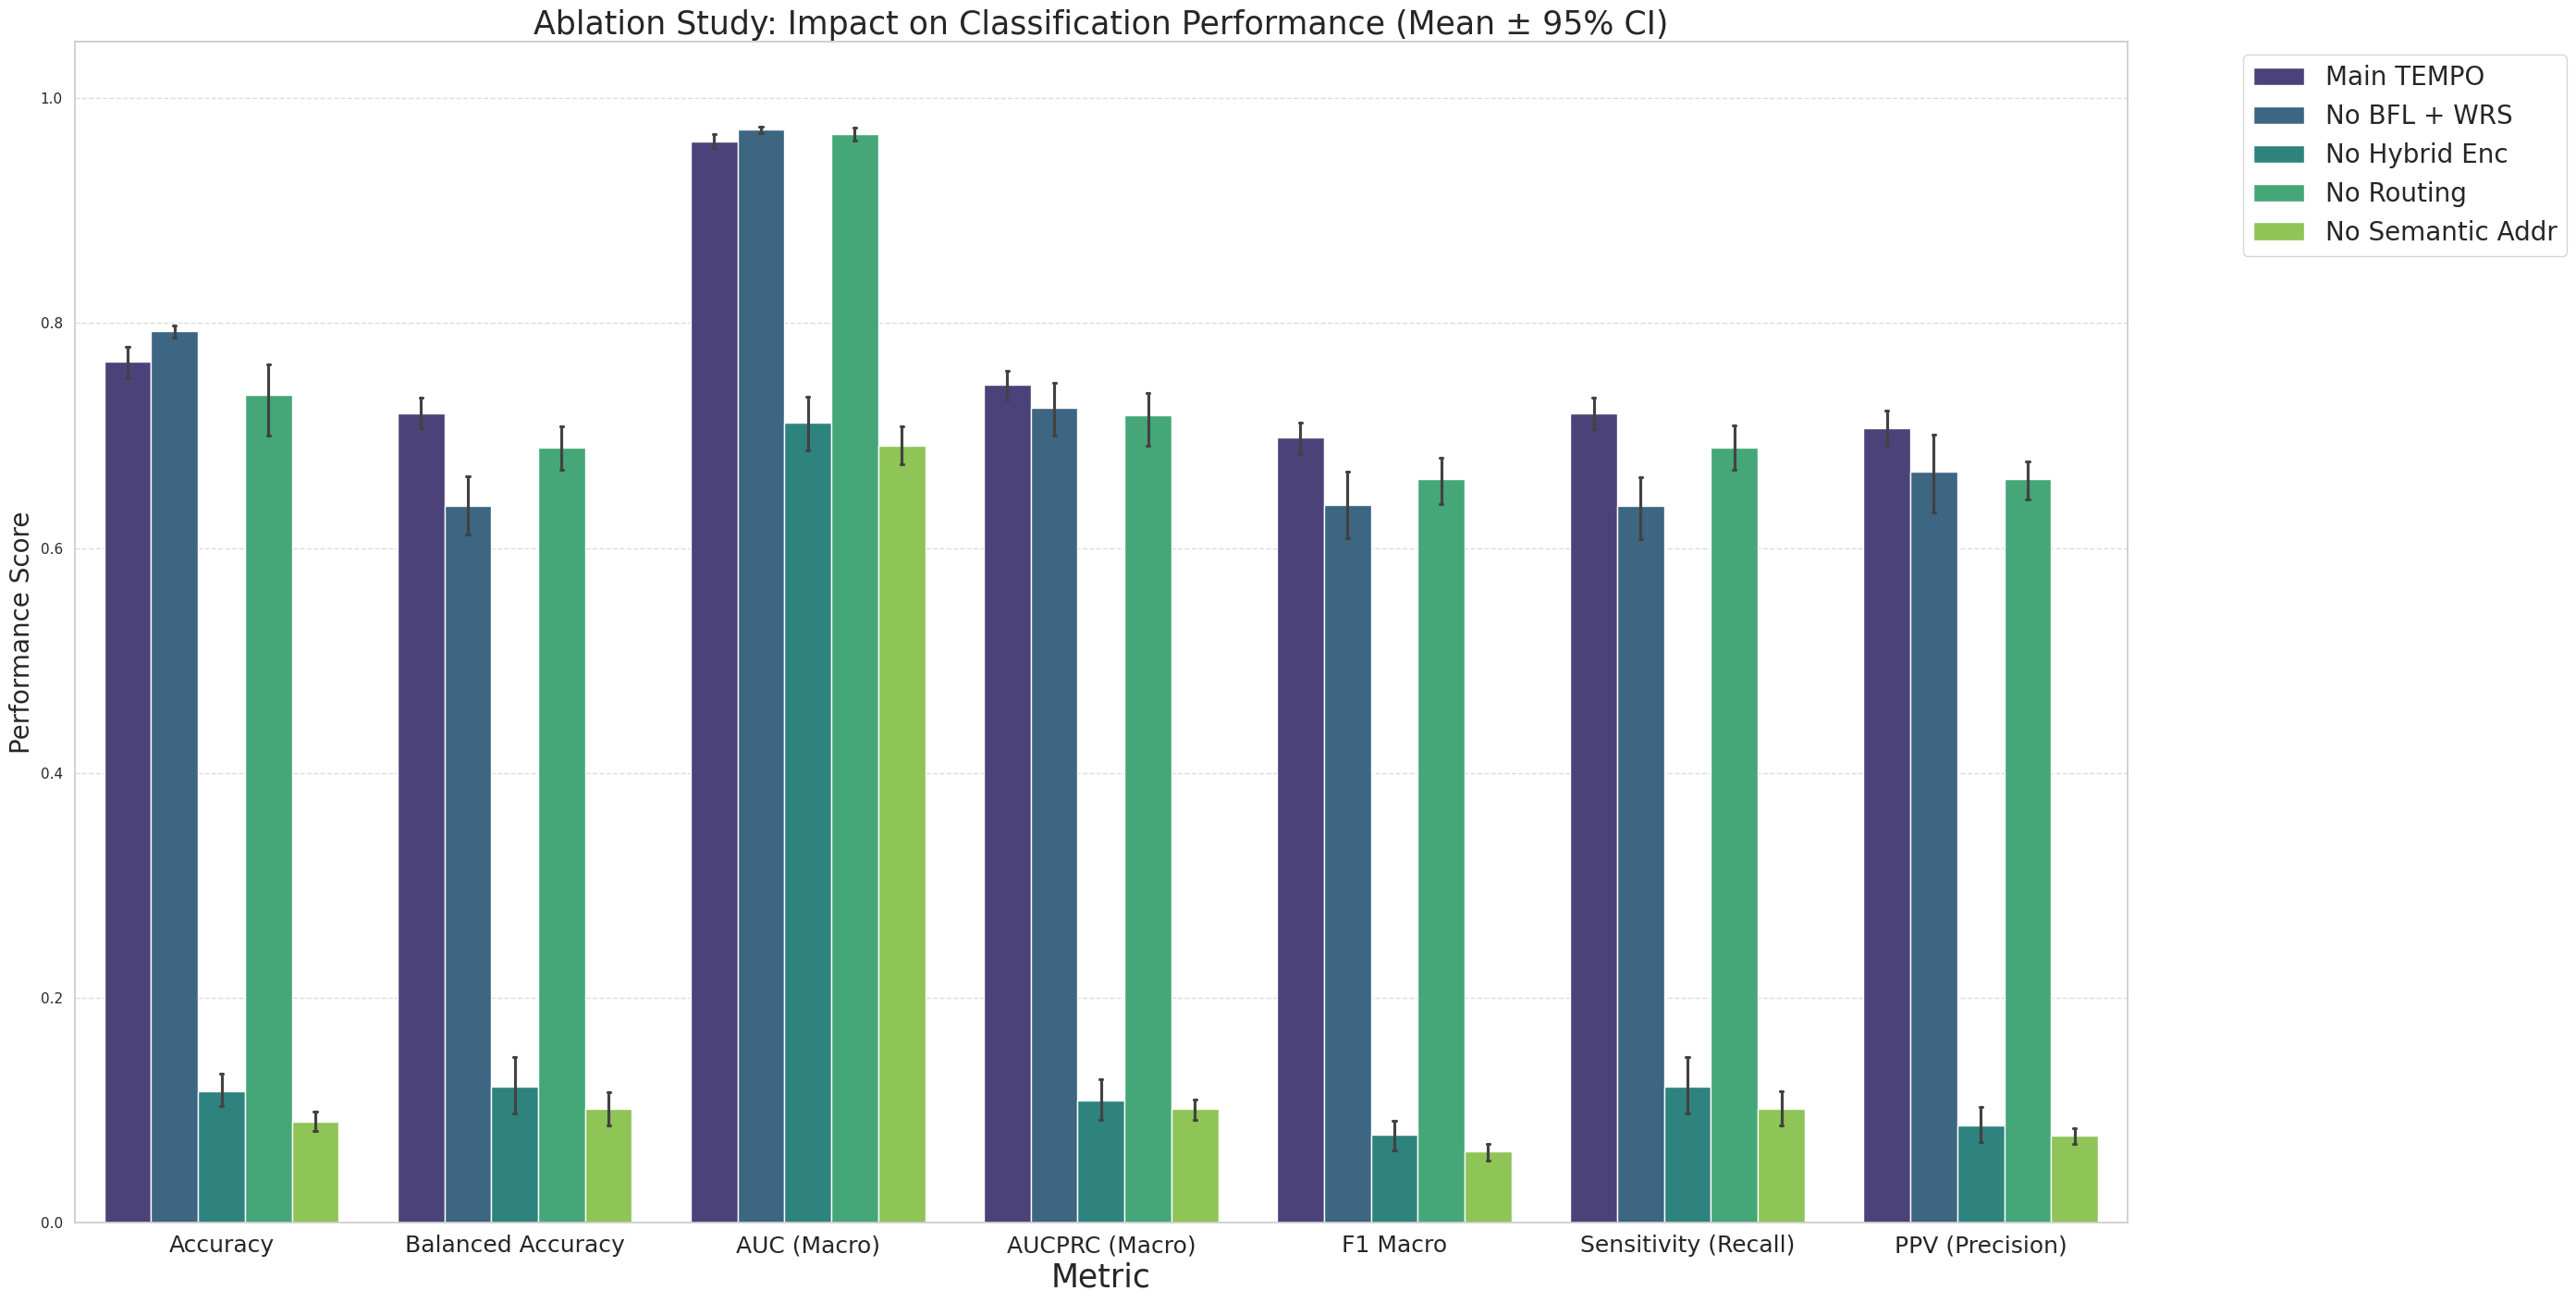

In [ ]:
# Melt data for easier plotting with Seaborn
melted_df = full_data.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(28, 14))
sns.barplot(data=melted_df, x='Metric', y='Score', hue='Model', palette='viridis', capsize=.05)
plt.title("Ablation Study: Impact on Classification Performance (Mean ± 95% CI)", fontsize=25)
plt.ylim(0, 1.05)
plt.ylabel("Performance Score",fontsize=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xticks(fontsize=18)
plt.xlabel("Metric",fontsize=25)
plt.savefig("Ablation_Metrics_Comparison.png",dpi = 300)

Visualize efficiency

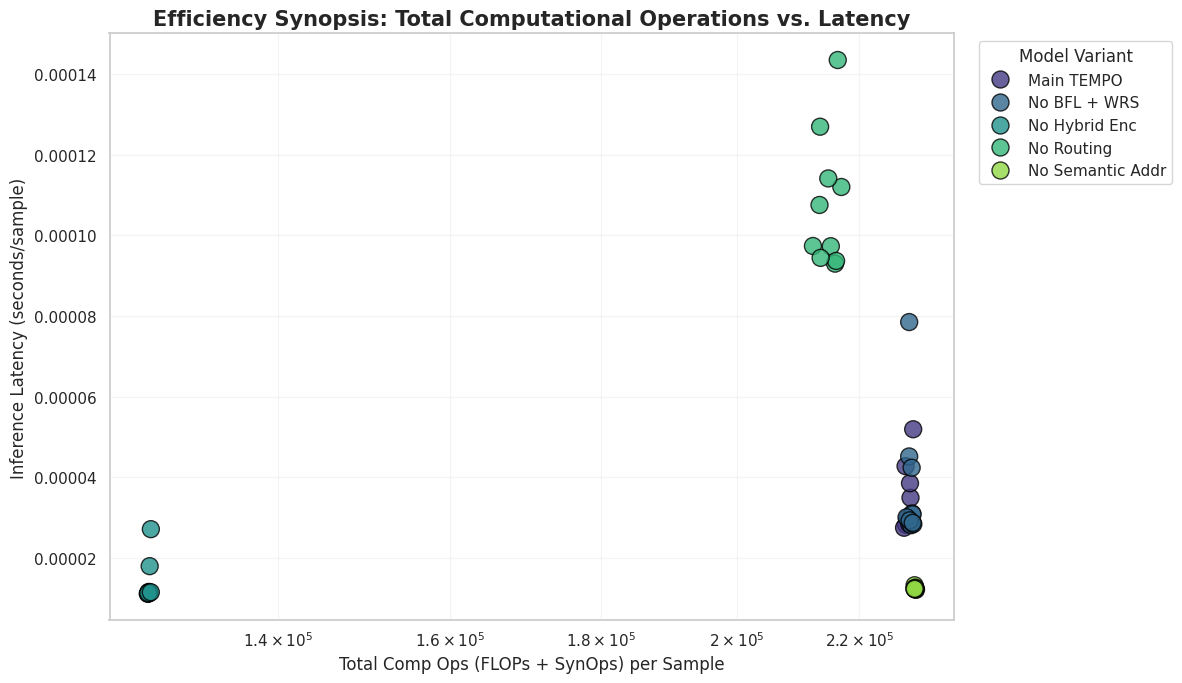

Updated Efficiency Synopsis:
                  Total Comp Ops   Latency  Accuracy
Model                                               
Main TEMPO         228667.870782  0.000034  0.765679
No BFL + WRS       229007.534979  0.000037  0.792840
No Hybrid Enc      126619.552428  0.000014  0.116708
No Routing         214767.305514  0.000108  0.735967
No Semantic Addr   229772.703539  0.000012  0.090206


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup uniform color mapping
# Ensures "No PURE LIF + No Routing" stays consistent across all visuals
colors = sns.color_palette("viridis", n_colors=full_data['Model'].nunique())
color_dict = dict(zip(full_data['Model'].unique(), colors))

# 2. Calculate the composite metric
# Total Comp Ops = FLOPs + SynOps (ensure units are aligned, e.g., both per sample)
full_data['Total Comp Ops'] = full_data['FLOPs/Sample'] + full_data['SynOps/Sample']

# 3. Visualization
fig, ax1 = plt.subplots(figsize=(12, 7))

# Scatter plot using the new Total Comp Ops metric
sns.scatterplot(
    data=full_data,
    x='Total Comp Ops',
    y='Latency',
    hue='Model',
    palette=color_dict,
    s=150,
    edgecolor='black',
    alpha=0.8,
    ax=ax1
)

# 4. Formatting and Logistics
ax1.set_title("Efficiency Synopsis: Total Computational Operations vs. Latency", fontsize=15, fontweight='bold')
ax1.set_xscale('log')  # Log scale for high variance in operation counts
ax1.set_xlabel("Total Comp Ops (FLOPs + SynOps) per Sample", fontsize=12)
ax1.set_ylabel("Inference Latency (seconds/sample)", fontsize=12)

# Professional grid and legend placement
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Model Variant", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig("Total_Comp_Ops_vs_Latency.png", dpi=300)
plt.show()

# 5. Updated Synopsis Export
synopsis = full_data.groupby('Model')[['Total Comp Ops', 'Latency', 'Accuracy']].mean()
print("Updated Efficiency Synopsis:")
print(synopsis)

Run Welsh T-Tests to determine statistical significance and visualize with heatmap

Welch's T-Test complete. Heatmap saved and CSV exported.


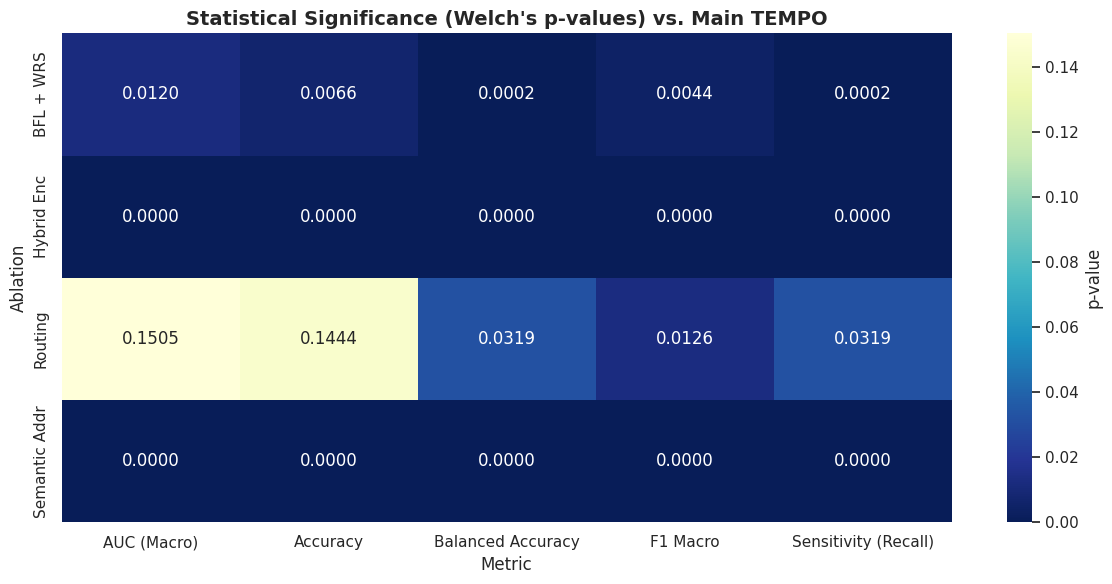

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Setup Mapping (Corrected Label for Router_Abalation)
file_map = {
    "Main TEMPO": "PANCAN_TEMPO_Metrics.csv",
    "BFL + WRS": "BFL_WRS_Abalation.csv",
    "Hybrid Enc": "Hybrid_Encoding_Abalation.csv",
    "Routing": "Router_Abalation.csv",
    "Semantic Addr": "Semantic_Addressing_Abalation.csv",
}

metrics = ["Accuracy", "Balanced Accuracy", "AUC (Macro)", "F1 Macro", "Sensitivity (Recall)"]

# 2. Load and Combine Data
dfs = []
for label, path in file_map.items():
    try:
        temp_df = pd.read_csv(path)
        temp_df['Model'] = label
        dfs.append(temp_df)
    except FileNotFoundError:
        print(f"Warning: {path} not found.")

full_data = pd.concat(dfs, ignore_index=True)

# 3. Statistical Test: Welch's T-Test (equal_var=False)
main_results = full_data[full_data['Model'] == "Main TEMPO"]
comparison_models = [m for m in full_data['Model'].unique() if m != "Main TEMPO"]

stats_summary = []

for model in comparison_models:
    model_results = full_data[full_data['Model'] == model]
    for metric in metrics:
        if metric in full_data.columns:
            # equal_var=False performs Welch's T-Test
            t_stat, p_val = stats.ttest_ind(
                main_results[metric].dropna(),
                model_results[metric].dropna(),
                equal_var=False
            )
            stats_summary.append({
                "Ablation": model,
                "Metric": metric,
                "p-value": p_val,
                "Significant (p<0.05)": "Yes" if p_val < 0.05 else "No"
            })

stats_df = pd.DataFrame(stats_summary)

# 4. Visualizing p-values as a Heatmap
p_pivot = stats_df.pivot(index="Ablation", columns="Metric", values="p-value")

plt.figure(figsize=(12, 6))
# Using a uniform color scheme (YlGnBu_r) where darker/blue indicates lower p-values (higher significance)
sns.heatmap(p_pivot, annot=True, cmap="YlGnBu_r", fmt=".4f", cbar_kws={'label': 'p-value'})
plt.title("Statistical Significance (Welch's p-values) vs. Main TEMPO", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Welch_Test_Significance_Heatmap.png",dpi=300)

# 5. Output results to CSV
stats_df.to_csv("Ablation_Welch_Tests.csv", index=False)

print("Welch's T-Test complete. Heatmap saved and CSV exported.")

Based on the results, we see that removing hybrid encoding results in major energy efficiency gains, but performance drops significantly. Removing semantic addressing resulted in poorer performance in regards to all of the performance and neuromorphic metrics as well as a loss of interpertability. While removing balanced focal learning and weighted random sampling had a slight (but insignificant) increase in raw accuracy, balanced accuracy and F1 macro plummeted. Removing differentiable categorial routing had the least negative impact on performance metrics and also minor efficiency gains. There was no statistical difference for AUC (Macro) and Accuracy, but Balanced Accuracy, F1 Macro, and Sensitivity were significantly lower, indicating struggles with class imbalance and stability.
